# 01 — Data Collection
This notebook downloads and saves the raw data for the Geopolitical Shock Commodity Predictor project. We collect three datasets: daily news headlines from ABC News (via Kaggle), and Crude Oil and Gold futures prices (via the yfinance API).

**Datasets covered:**
- ABC News Headlines (2003–2021) — ~1.2M headlines
- Crude Oil Futures (CL=F) — daily OHLCV data
- Gold Futures (GC=F) — daily OHLCV data

---
## Setup & Configuration

Import required libraries and configure project directory paths. The BASE_DIR logic ensures the notebook works correctly whether run from the notebooks/ folder or the project root.

In [ ]:
import yfinance as yf
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


BASE_DIR = Path().resolve()


if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_RAW.mkdir(parents=True, exist_ok=True)

---
## Download Commodity Prices

Download daily historical prices for Crude Oil (CL=F) and Gold (GC=F) futures from 2003 to 2021 using the yfinance API. The data is saved as CSV files in data/raw/.

In [12]:
crude = yf.download("CL=F", start="2003-01-01", end="2021-12-31")
gold = yf.download("GC=F", start="2003-01-01", end="2021-12-31")

crude.reset_index(inplace=True)
gold.reset_index(inplace=True)

crude.to_csv(DATA_RAW / "crude_oil_prices.csv", index=False)
gold.to_csv(DATA_RAW / "gold_prices.csv", index=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


---
## Load News Headlines

Load the ABC News headlines dataset (downloaded from Kaggle). This dataset contains over 1.2 million headlines spanning 2003–2021, which we will later use to extract geopolitical risk signals.

In [13]:
news_path = DATA_RAW / "abcnews-date-text.csv"
news = pd.read_csv(news_path)

print("🔹 News Preview:")
print(news.head())

🔹 News Preview:
   publish_date                                      headline_text
0      20030219  aba decides against community broadcasting lic...
1      20030219     act fire witnesses must be aware of defamation
2      20030219     a g calls for infrastructure protection summit
3      20030219           air nz staff in aust strike for pay rise
4      20030219      air nz strike to affect australian travellers


---
## Dataset Summaries & Validation

Verify all three datasets loaded correctly by checking shapes, date ranges, and null values. This is our first quality gate — catching issues here prevents problems downstream.

In [14]:
def dataset_summary(df, name):
    print(f"\n📊 {name} Summary:")
    print("Shape:", df.shape)

    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        print("Date Range:", df['Date'].min(), "→", df['Date'].max())
    elif 'publish_date' in df.columns:
        df['publish_date'] = pd.to_datetime(df['publish_date'], format='%Y%m%d', errors='coerce')
        print("Date Range:", df['publish_date'].min(), "→", df['publish_date'].max())
    else:
        print("Date Range: Not found")

    print("\nNull Values:")
    print(df.isnull().sum())


dataset_summary(crude, "Crude Oil")
dataset_summary(gold, "Gold")
dataset_summary(news, "News")


📊 Crude Oil Summary:
Shape: (4775, 6)
Date Range: 2003-01-02 00:00:00 → 2021-12-30 00:00:00

Null Values:
Price   Ticker
Date              0
Close   CL=F      0
High    CL=F      0
Low     CL=F      0
Open    CL=F      0
Volume  CL=F      0
dtype: int64

📊 Gold Summary:
Shape: (4771, 6)
Date Range: 2003-01-02 00:00:00 → 2021-12-30 00:00:00

Null Values:
Price   Ticker
Date              0
Close   GC=F      0
High    GC=F      0
Low     GC=F      0
Open    GC=F      0
Volume  GC=F      0
dtype: int64

📊 News Summary:
Shape: (1244184, 2)
Date Range: 2003-02-19 00:00:00 → 2021-12-31 00:00:00

Null Values:
publish_date     0
headline_text    0
dtype: int64


---
## Daily News Volume Analysis

Analyze how many headlines are published per day. Consistent daily coverage is critical — large gaps mean our model would have 'blind spots' where no news signal exists.

The Average Headlines per Day: 180.8
The Fewest Headlines in One Day: 1
The Most Headlines in One Day: 384
Total Number of Uniqe Days with News: 6882


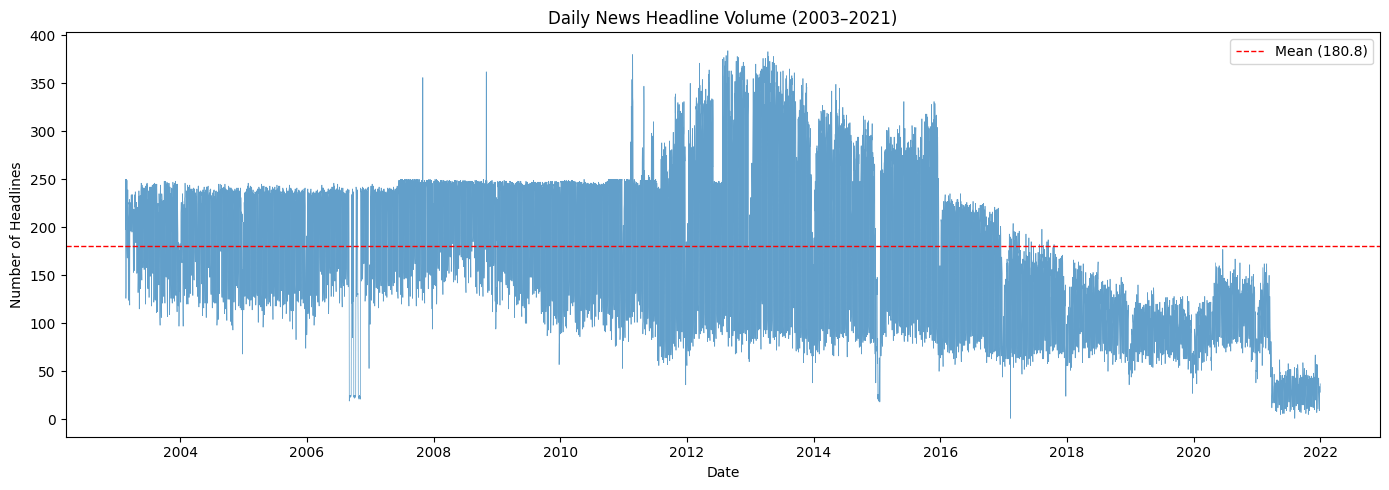

In [21]:
daily_counts = news.groupby('publish_date')["headline_text"].count()

print(f'The Average Headlines per Day: {daily_counts.mean():.1f}')
print(f'The Fewest Headlines in One Day: {daily_counts.min()}')
print(f'The Most Headlines in One Day: {daily_counts.max()}')
print(f'Total Number of Uniqe Days with News: {daily_counts.shape[0]}')

plt.figure(figsize=(14, 5))
plt.plot(daily_counts.index, daily_counts.values, linewidth=0.5, alpha=0.7)
plt.axhline(y=daily_counts.mean(), linewidth=1, color='red', linestyle="--", label=f'Mean ({daily_counts.mean():.1f})')
plt.title('Daily News Headline Volume (2003–2021)')
plt.xlabel('Date')
plt.ylabel('Number of Headlines')
plt.tight_layout()
plt.legend()
plt.show()